<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/Logarithm_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2025 Germán Almanza ralmanza@uacj.mx


# **Forma funcional no-lineal (logaritmos)**

Continuamos con el análisis de las formas funcionales no-lineales. Vamos a analizar datos de **California Standardized Testing and Reporting**, esta base de datos contiene información sobre el desempeño en las pruebas, las características de las escuelas y los antecedentes demográficos de los estudiantes. Los datos utilizados aquí provienen de los 420 distritos de K-6 y K-8 de California con datos disponibles para 1999.

* *testscr* son el promedio de las calificaciones de lectura y matemáticas en la Prueba de Logros Stanford 9, una prueba estandarizada administrada a los estudiantes de quinto grado.

* *avginc* es el ingreso per cápita anual promedio en el distrito escolar, medido en miles de dólares de 1998.

Las características de las escuelas (promediadas en todo el distrito) incluyen la matrícula, el número de maestros (medido como "equivalentes de tiempo completo"), el número de computadoras por aula y los gastos por estudiante. La proporción de estudiantes por maestro utilizada aquí es el número de estudiantes en el distrito dividido por el número de maestros equivalentes a tiempo completo. Las variables demográficas de los estudiantes también se promedian en todo el distrito. Las variables demográficas incluyen el porcentaje de estudiantes que participan en el programa de asistencia pública *CalWorks* (anteriormente *AFDC*), el porcentaje de estudiantes que califican para un almuerzo a precio reducido y el porcentaje de estudiantes que son estudiantes de inglés (es decir, estudiantes para quienes el inglés es su segunda lengua). Todos estos datos se obtuvieron del [California Department of Education](https://www.cde.ca.gov).

In [ ]:
#       1.
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#       2.
import pandas as pd

path="/content/drive/MyDrive/Colab Notebooks/DataSets/caschool.csv"
CA9899=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DataSets/caschool.csv")
CA9899

,observation_number,dist_cod,county,district,gr_span,enrl_tot,teachers,calw_pct,meal_pct,computer,testscr,comp_stu,expn_stu,str,avginc,el_pct,read_scr,math_scr
0,1,75119,Alameda,Sunol Glen Unified,KK-08,195,10.900000,0.510200,2.040800,67,690.799988,0.343590,6384.911133,17.889910,22.690001,0.000000,691.599976,690.000000
1,2,61499,Butte,Manzanita Elementary,KK-08,240,11.150000,15.416700,47.916698,101,661.200012,0.420833,5099.380859,21.524664,9.824000,4.583333,660.500000,661.900024
2,3,61549,Butte,Thermalito Union Elementary,KK-08,1550,82.900002,55.032299,76.322601,169,643.599976,0.109032,5501.954590,18.697226,8.978000,30.000002,636.299988,650.900024
3,4,61457,Butte,Golden Feather Union Elementary,KK-08,243,14.000000,36.475399,77.049202,85,647.700012,0.349794,7101.831055,17.357143,8.978000,0.000000,651.900024,643.500000
4,5,61523,Butte,Palermo Union Elementary,KK-08,1335,71.500000,33.108601,78.427002,171,640.849976,0.128090,5235.987793,18.671329,9.080333,13.857677,641.799988,639.900024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415,416,68957,San Mateo,Las Lomitas Elementary,KK-08,984,59.730000,0.101600,3.556900,195,704.300049,0.198171,7290.338867,16.474134,28.716999,5.995935,700.900024,707.700012
416,417,69518,Santa Clara,Los Altos Elementary,KK-08,3724,208.479996,1.074100,1.503800,721,706.750000,0.193609,5741.462891,17.862625,41.734108,4.726101,704.000000,709.500000
417,418,72611,Ventura,Somis Union Elementary,KK-08,441,20.150000,3.563500,37.193802,45,645.000000,0.102041,4402.831543,21.885857,23.733000,24.263039,648.299988,641.700012
418,419,72744,Yuba,Plumas Elementary,KK-08,101,5.000000,11.881200,59.405899,14,672.200012,0.138614,4776.336426,20.200001,9.952000,2.970297,667.900024,676.500000


In [ ]:
round(CA9899.describe(),2)
#CA9899

# **Correlación entre las variables de interés**

In [ ]:
import numpy as np

testscr=CA9899['testscr']
avginc=CA9899['avginc']

rho=np.corrcoef(testscr,avginc)[0,1]
print(f'Coeficiente de correlación de Pearson={round(rho, 4)}\n')


##**1. Regresión lineal**

##$$testscr=\beta_0+\beta_1 avginc+ u$$


In [ ]:
import statsmodels. formula.api as stf
import numpy as np

# estimacion modelo lineal-lineal:
reg_lineal=stf.ols('testscr~avginc', data=CA9899).fit()
reg_lineal.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                testscr   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     430.8
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           2.75e-66
Time:                        03:00:10   Log-Likelihood:                -1684.5
No. Observations:                 420   AIC:                             3373.
Df Residuals:                     418   BIC:                             3381.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    625.3836      1.532    408.106      0.000     622.371     628.396
avginc         1.8785      0.091     20.756      0.000       1.701       2.056
==============================================================================
Omnibus:                        2.473   Durbin-Watson:                   0.650
Prob(Omnibus):                  0.290   Jarque-Bera (JB):                2.480
Skew:                          -0.148   Prob(JB):                        0.289
Kurtosis:                       2.766   Cond. No.                         39.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### **Fórmula del Error Estandar del estimador $\hat\beta_1$**


En la regresión lineal simple $y=\hat\beta_0+\hat\beta_1x$,
el **error estándar de la estimación**  ee$(\hat\beta_1)$ es la variación  de las observaciones $y_i$ alrededor de los valores estimados $\hat y_i$  (línea de regresión), <mark>un ee$(\hat\beta_1)$ "pequeño" indica una estimación confiable respecto a la población</mark> y corresponde al cociente

$$ee(\hat\beta_1)=\sqrt{\frac{\widehat{\sigma}^2}{\sum (x_i-\bar x)^2}},
\quad\text{donde}\quad
\widehat{\sigma}^2=\frac{\sum \widehat{u}^2_i}{n-2}$$

* $\widehat{\sigma}^2:$ estimador de la varianza del residual al cuadrado.

Además, observa que $\sum_{i=1}^n (x_i-\bar x)^2=(n-1)var(x)$.


### **Comandos de python:**

* `.bse` **Error estandard** de los estimadores.
* `.ssr` *sum of squared residuals* calcula $\sum \widehat{u}^2_i$.
* `.df_resid` *residual degree of freedom* calcula los grados de libertad de la regresión, para regresión lineal simple es $(n-2)$.
*  `.nobs` asigna el número de observaciones de la regresión.

En las siguientes celdas presentamos dos formas para obtener el **error estandar del estimador $\beta_1$**.


In [ ]:
sigma2=reg_lineal.ssr/reg_lineal.df_resid
var_x=np.var(CA9899['avginc'],ddof=1)
N=reg_lineal.nobs
ee_beta1=np.sqrt(sigma2/((N-1)*var_x))
round(ee_beta1,3)


In [ ]:
avginc_mean=np.mean(avginc)
avginc_tss = np.sum((avginc-avginc_mean)**2)
avginc_ee=(sigma2/avginc_tss)**(1/2)
avginc_ee=round(avginc_ee,3)
avginc_ee

#avginc_tss

##**Tabla con valores de interés**

De momento solo nos interesan los valores de los estimadores (los $\beta_i$), sus p-values y el $R^2$ de la regresión. Estos valores los podemos poner en una trabla de la siguienta manera.

En la siguiente celda, definiremos las variables con los valores de los estimadores, para llamarlos dentro de la gráfica posteriormente.

In [ ]:
# Tabla Regresión lineal:
Table01=pd.DataFrame({'beta': round(reg_lineal.params, 2),
                      'sigma': round(reg_lineal.bse, 4),
                      't-val': round(reg_lineal.tvalues, 4),
                      'p-val': round(reg_lineal.pvalues, 4)})
#     Presenta la tabla y el R-squared
print(f'Tabla lin-lin: \n{Table01}\n')
Rsqrt=round(reg_lineal.rsquared, 4)
print(f'R^2={Rsqrt}\n')

# Definir variable-estimadores
Betas=Table01['beta'].reset_index(drop=True)
Betas
B0=Betas[0]
B1=Betas[1]


Tabla lin-lin: 
             beta   sigma     t-val  p-val
Intercept  625.38  1.5324  408.1060    0.0
avginc       1.88  0.0905   20.7565    0.0

R^2=0.5076



## **1.2 Interpretación de la regresión lineal:**

Comenzamos por observar que los estimadores tiene $p-values< 0.01$, por otra parte la ecuación   
$$y=625.38+1.87x$$
<mark>significa que por cada incremento de 1mil dolares del ingreso $x$ en el distrito escolar, el promedio de las calificaciones de los estudiantes incrementa en $1.87$ puntos. </mark>El intercepto $\beta_0=625.38$ señala que cuando el ingreso/presupuesto promedio  de los distritos escolares ($x\approx0$) es muy bajo (casi nulo), el promedio de calificación de los estudiantes de ese distrito se estima en $625.38$ puntos. El $R^2=0.507$ señala que la regresión estima poco más del $50\%$ de las observaciones.


## **1.3 Gráfica regresión lineal**

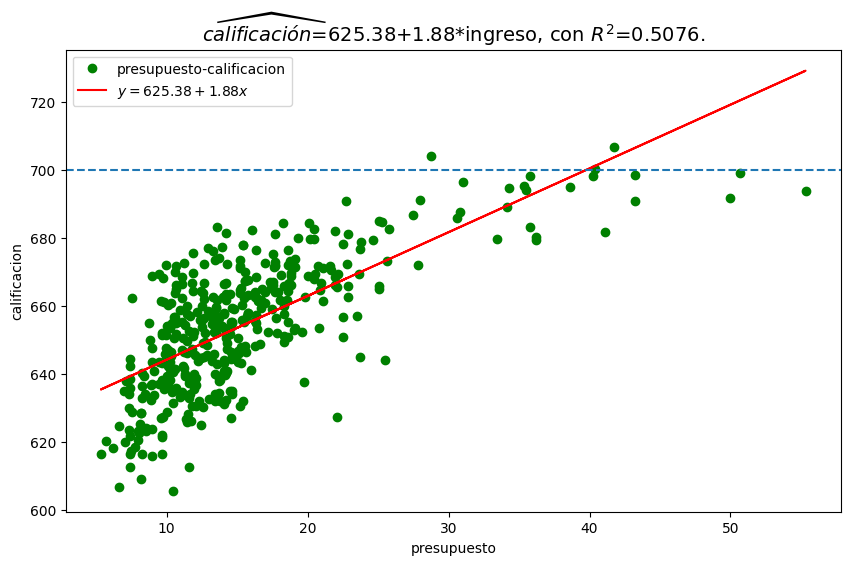

In [ ]:
import matplotlib.pyplot as plt

#hours~lwage
plt.figure(figsize=(10,6))

plt.plot('avginc','testscr',data=CA9899,color='g',marker='o',linestyle='',label='presupuesto-calificacion')
plt.plot(CA9899['avginc'],reg_lineal.fittedvalues,color='red',linestyle='-',label=f'$y={B0}+{B1}x$')

plt.axhline(y=700,linestyle='--')

plt.ylabel ('calificacion')
plt.xlabel ('presupuesto')
#   titulo
plt.title(r'$\widehat{calificación}$'f'={B0}+{B1}*ingreso, con ' r'$R^2$='f'{Rsqrt}.', size=14)
plt.legend()
plt.savefig('Lineal_CI.jpg')
plt.show()

# **2. Modelo de regresión lin-log:**


Llamamos modelo de regresión **Lin-Log** a la regresión de OLS donde aplicamos logaritmo a la variable independiente $\ln(x)$ y dejamos lineal la variable dependiente. Es decir, dada la variable $x$ tenemos el valor de
$$y=\beta_0+ \beta_1 \ln(x).$$
Al considerar el incremento $\Delta x$, tenemos el incremento en $y$ definido por
$$y+\Delta y=\beta_0+ \beta_1 \ln(x+\Delta x).$$
De modo que

$$\Delta y=(y+\Delta y)-y
          =\Big(\beta_0+ \beta_1 \ln(x+\Delta x)\Big)-
           \Big(\beta_0+ \beta_1 \ln(x)\Big)
           =\beta_1 \Big(\ln(x+\Delta x)-\ln(x)\Big).
\quad\implies\quad
\Delta y=\beta_1 \ln(1+\tfrac{\Delta x}{x})       $$

<br>

---
<br>
<mark> Observa que el cociente $\tfrac{\Delta x}{x}$ representa un incremento porcentual</mark>; es decir, si $\Delta x=5$ entonces   $\tfrac{\Delta x}{x}=0.05$. Por lo tanto,
<mark>
un incremento porcentual $\tfrac{\Delta x}{x}$ en $x$, corresponde con el incremento $\beta_1\ln(1+\tfrac{\Delta x}{x})$ en $y$.</mark>

---
<br>

##**2.1 Regresión lineal-log**

##$$testscr=\beta_0+\beta_1 \ln(avginc)+ u$$


In [ ]:
# estimacion modelo lineal-log:
reg_linlog=stf.ols('testscr~np.log(avginc)', data=CA9899).fit()
reg_linlog.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                testscr   R-squared:                       0.563
Model:                            OLS   Adj. R-squared:                  0.561
Method:                 Least Squares   F-statistic:                     537.4
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           4.77e-77
Time:                        03:01:08   Log-Likelihood:                -1659.7
No. Observations:                 420   AIC:                             3323.
Df Residuals:                     418   BIC:                             3331.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        557.8323      4.200    132.806      0.000     549.576     566.089
np.log(avginc)    36.4197      1.571     23.183      0.000      33.332      39.508
==============================================================================
Omnibus:                        0.548   Durbin-Watson:                   0.991
Prob(Omnibus):                  0.760   Jarque-Bera (JB):                0.388
Skew:                          -0.059   Prob(JB):                        0.824
Kurtosis:                       3.091   Cond. No.                         20.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# tabla regresión lin-log:
Table02=pd.DataFrame({'beta': round(reg_linlog.params, 2),
                      'sigma': round(reg_linlog.bse, 4),
                      't-val': round(reg_linlog.tvalues, 4),
                      'p-val': round(reg_linlog.pvalues, 4)})

print(f'Tabla lin-log: \n{Table02}\n')
print(f'R^2={round(reg_linlog.rsquared, 4)}\n')

# Definir variable-estimadores
Betasl=Table02['beta'].reset_index(drop=True)
Bl0=Betasl[0]
Bl1=Betasl[1]
Rsqrt_Bl=round(reg_linlog.rsquared, 4)

Tabla lin-log: 
                  beta   sigma     t-val  p-val
Intercept       557.83  4.2003  132.8062    0.0
np.log(avginc)   36.42  1.5710   23.1828    0.0

R^2=0.5625



In [ ]:
incr=10/100
Bl1*np.log(1+incr)

## **2.2 Interpretación del modelo lin-log**

Comenzamos por observar que los estimadores tiene $p-values< 0.01$, por otra parte la ecuación   
$$y=557.83+36.41\ln(x)$$
<mark>significa que un incremento del $1\%$ en el ingreso del distrito escolar, el promedio de las calificaciones de los estudiantes incrementa en $36.41\times\ln(1.01)=0.3622$ puntos.</mark>

* **Observación 1:** cuando introducimos $\ln(x)$ en la regresión, estamos agregando un efecto porcentual en las estimaciones.

Tiene más sentido considerar el siguiente enunciado. Un incremento del $10\%$ en el ingreso del distrito escolar, incrementa el promedio de las calificaciones de los estudiantes  en $36.41\times\ln(1.10)=3.47$ puntos.

Por otra parte, el intercepto $\beta_0=557.83$, aunque es estadísticamente significativo, no tiene una interpretación concreta. Ya que, el valor mínimo de la variable *testscr* es $605.55$ pts, mientras que resulta absurdo que una escuela pública tenga un presupuesto/ingreso nulo.

`CA9899['testscr'].min()`

`output: 605.55`

Finalmente, el $R^2=0.5625$ señala que $\ln(avginc)$ explica poco más del $56.2\%$ de las observaciones *testscr*.

* **Observación 2:** En la interpretación de los estimadores no se menciona $\ln(x)$, solo se hace referencia implicitamente en la interpretación porcentual de los estimadores.


La diferencia entre la interpretación
*  lineal $\Delta x/x$, y
*  logaritmo $\ln(1+\Delta x/x)$

de la regresión lin-log, es más clara si  consideramos el incremento
$\Delta x=10$, entonces hacemos los  cálculos siguientes

*  $36.41\times 0.1$=3.64
*  $36.41\times \ln(1.1)$=3.47

In [ ]:
ap_linB1=36.41*.1
ap_logB1=36.41*np.log(1+.10)

print('Con un incremento del 10% en el presupuesto escolar anual, \n'
      f'la "aproximación lineal" señala un incremento de {ap_linB1:.2f} \npuntos en las calificaciones de estudiantes.\n')

print('Con un incremento del 10% en el presupuesto escolar anual, \n'
      f'la "aproximación logaritmo" señala un incremento de {ap_logB1:.2f} \npuntos en las calificaciones de estudiantes.')




## **2.3 Gráfica de la regresión lin-log**

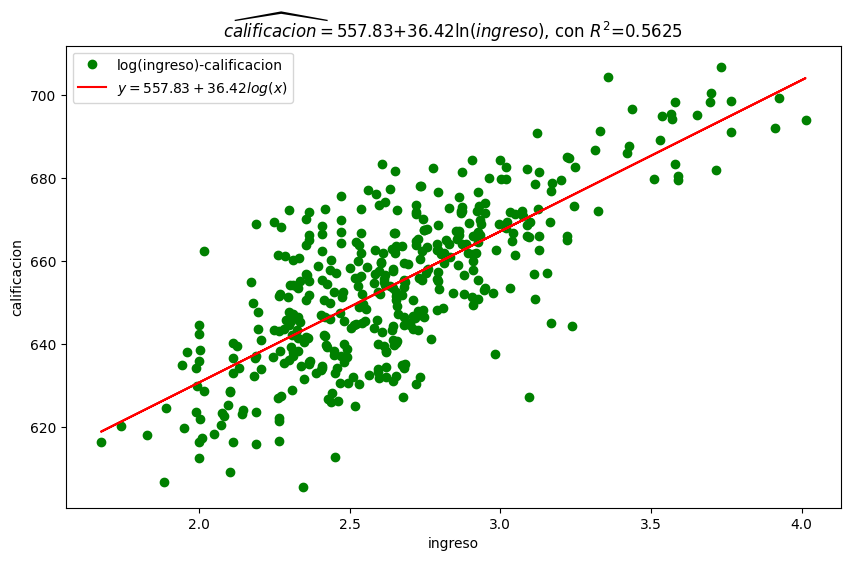

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

x=np.arange(5,56, 0.1)
y=Bl0+Bl1*np.log(x)

plt.plot(np.log(avginc),'testscr',data=CA9899,color='g',marker='o',linestyle='',label='log(ingreso)-calificacion')
plt.plot(np.log(CA9899['avginc']),reg_linlog.fittedvalues,color='red',linestyle='-',label=f'$y={Bl0}+{Bl1}log(x)$')

plt.ylabel ('calificacion')
plt.xlabel ('ingreso')
#   titulo
plt.title(r'$\widehat{calificacion}=$'f'{Bl0}+{Bl1}' r'$\ln(ingreso)$, con $R^2$='f'{Rsqrt_Bl}', size=12)

plt.legend()
plt.savefig('Lineal_IC2.pdf')
plt.show()

## **2.4 Gráfica de la curva de ajuste lin-log**

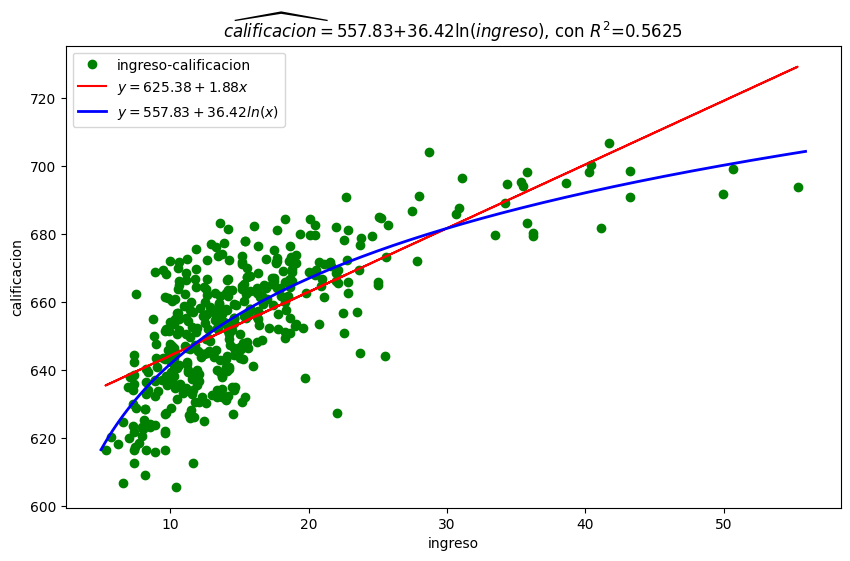

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

x=np.arange(5,56, 0.1)
y=Bl0+Bl1*np.log(x)

plt.plot('avginc','testscr',data=CA9899,color='g',marker='o',linestyle='',label='ingreso-calificacion')
plt.plot(CA9899['avginc'],reg_lineal.fittedvalues,color='red',linestyle='-',label=f'$y={B0}+{B1}x$')
plt.plot(x, y, color='b',label=f'$y={Bl0}+{Bl1}ln(x)$',linewidth=2)

plt.ylabel ('calificacion')
plt.xlabel ('ingreso')
#   titulo
plt.title(r'$\widehat{calificacion}=$'f'{Bl0}+{Bl1}' r'$\ln(ingreso)$, con $R^2$='f'{Rsqrt_Bl}', size=12)

plt.legend()
plt.savefig('Lineal_IC2.pdf')
plt.show()

# **3. Modelo log-lin**


En la forma funcional **log-lin** (anteriormente) establecimos la siguiente interpretación

<mark> El incremento $\Delta x$ corresponde a una  variación en $y$ de $(100\times \beta_1\Delta x )\%$. </mark>

<br>

Lo anterior porque utilizamos la aproximación
$$\frac{\Delta y}{y}\approx
  \ln(y+\Delta y)-\ln(y),\qquad (\heartsuit)$$
en la diferencia de logaritmos
$$\ln(y+\Delta y)-\ln(y)=\beta_0+\beta_1 (x+\Delta x)-\beta_0-\beta_1 x
=\beta_1 \Delta x  \qquad (1)$$
para obtener
$$\frac{\Delta y}{y}=\beta_1 \Delta x.$$

<br>

---

<br>


Si buscamos mayor precisión, la diferencia de logaritmos (1) queda como
$$\ln\big(\frac{y+\Delta y}{y}\big)=\beta_1 \Delta x
\quad\implies\quad
\frac{\Delta y}{y}=\exp(\beta_1 \Delta x)-1
 \qquad (2)$$

<mark>
La ecuación (2) nos dice que el incremento $\Delta x$ corresponde al
cambio porcentual en $y$ definido por $100\times\big(\exp(\beta_1\cdot\Delta x)-1\big)\%$.
</mark>

---
---


##**3.1 Regresión log-lineal**

##$$\ln(testscr)=\beta_0+\beta_1 avginc+ u$$


In [ ]:
# estimacion modelo log-lin:
reg_loglin=stf.ols('np.log(testscr)~avginc', data=CA9899).fit()
reg_loglin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        np.log(testscr)   R-squared:                       0.498
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     415.0
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           1.41e-64
Time:                        03:08:55   Log-Likelihood:                 1034.7
No. Observations:                 420   AIC:                            -2065.
Df Residuals:                     418   BIC:                            -2057.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.4394      0.002   2724.161      0.000       6.435       6.444
avginc         0.0028      0.000     20.372      0.000       0.003       0.003
==============================================================================
Omnibus:                        3.487   Durbin-Watson:                   0.627
Prob(Omnibus):                  0.175   Jarque-Bera (JB):                3.538
Skew:                          -0.200   Prob(JB):                        0.171
Kurtosis:                       2.795   Cond. No.                         39.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# tabla regresión log-lin:
Table03=pd.DataFrame({'beta': round(reg_loglin.params, 4),     #3
                      'sigma': round(reg_loglin.bse, 4),
                      't-val': round(reg_loglin.tvalues, 4),
                      'p-val': round(reg_loglin.pvalues, 4)})

print(f'Tabla log-lin: \n{Table03}\n')
print(f'R^2={round(reg_loglin.rsquared, 4)}\n')

# Definir variable-estimadores
lBetas=Table03['beta'].reset_index(drop=True)
lB0=lBetas[0]
lB1=lBetas[1]
Rsqrt_lB=round(reg_loglin.rsquared, 4)

Tabla log-lin: 
             beta   sigma      t-val  p-val
Intercept  6.4394  0.0024  2724.1613    0.0
avginc     0.0028  0.0001    20.3720    0.0

R^2=0.4982



##**3.2- Interpretación del modelo log-lin**

El análisis de interpretación es bastante similar al análisis de la regresión lineal-log.
Comenzamos por observar que los estimadores tiene $p-values< 0.01$, por otra parte la ecuación   
$$\ln(y)=6.4394+0.0028x$$
<mark>significa que un incremento de una unidad en el presupuesto/ingreso del distrito escolar, corresponde con un incremento de $100\times(\exp(0.0028\cdot1)-1)\approx0.28=28\%$  en el promedio de las calificaciones de los estudiantes.</mark>

El $R^2=0.4982$ nos dice que el modelo explica poco menos del $50\%$ de las observaciones.



##**3.3- Grafica de la regresión log-lin**


<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipython-input-1111/2497062427.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(CA9899['avginc'],reg_loglin.fittedvalues,color='red',linestyle='-',label=f'$\log(y)={lB0}+{lB1}x$')


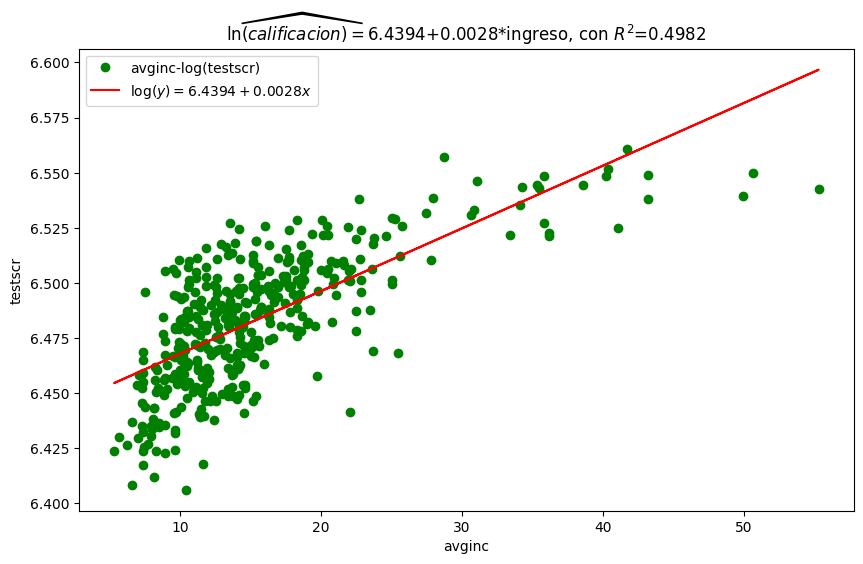

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot('avginc',np.log(testscr),data=CA9899,color='g',marker='o',linestyle='',label='avginc-log(testscr)')
plt.plot(CA9899['avginc'],reg_loglin.fittedvalues,color='red',linestyle='-',label=f'$\log(y)={lB0}+{lB1}x$')

plt.ylabel ('testscr')
plt.xlabel ('avginc')
#   titulo
plt.title(r'$\widehat{\ln(calificacion)}=$'f'{lB0}+{lB1}*ingreso, con ' r'$R^2$='f'{Rsqrt_lB}', size=12)

#plt.title(f'$\widehat\ln(testscr)={lB0}+{lB1}\widehat\ln(avginc)$', size=16)

plt.legend()
plt.savefig('Lineal_IC4.jpg')
plt.show()

##**3.4- Curva de ajuste del modelo log-lin**


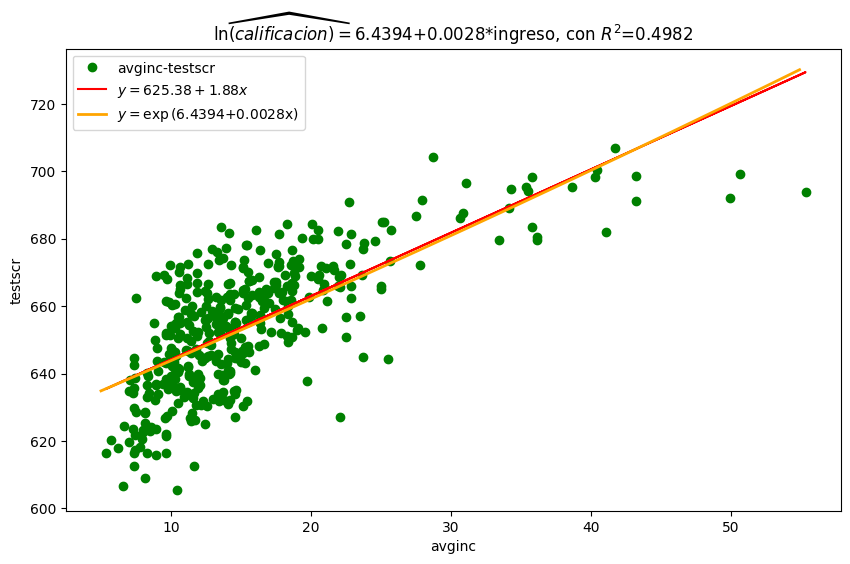

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

x=np.arange(5,55, 0.1)
#y=lB0+lB1*np.log(x)
#ly=np.exp(llB0+llB1*np.log(x))
ly=np.exp(lB0+lB1*x)

plt.plot('avginc','testscr',data=CA9899,color='g',marker='o',linestyle='',label='avginc-testscr')
plt.plot(CA9899['avginc'],reg_lineal.fittedvalues,color='red',linestyle='-',label=f'$y={B0}+{B1}x$')
plt.plot(x, ly, color='orange',label=r'$y=\exp$'f'({lB0}+{lB1}x)',linewidth=2)

plt.ylabel ('testscr')
plt.xlabel ('avginc')
#   titulo
plt.title(r'$\widehat{\ln(calificacion)}=$'f'{lB0}+{lB1}*ingreso, con ' r'$R^2$='f'{Rsqrt_lB}', size=12)

#plt.title(f'$\widehat\ln(testscr)={lB0}+{lB1}\widehat\ln(avginc)$', size=16)

plt.legend()
plt.savefig('Lineal_IC4.jpg')
plt.show()

# **4. Modelo de regresión log-log**


Dado $x$ y su incremento $x+\Delta x$, los varlores esperadoes en $y$ con la **regresión log-log** son
$$\ln(y)=\beta_0+\beta_1\ln(x)$$
y
$$\ln(y+\Delta y)=\beta_0+\beta_1\ln(x+\Delta x),$$
respectivamente. Realizamos la diferencia
$$\ln(y+\Delta y)-\ln(y)=
\beta_0+\beta_1\ln(x+\Delta x)-
\beta_0-\beta_1\ln(x)=
\beta_1[\ln(x+\Delta x)-\ln(x)]
\quad\implies\quad
\ln\big(\tfrac{y+\Delta y}{y}\big)=
\beta_1\ln\big(\tfrac{x+\Delta x}{x}\big).$$
Aplicando la función exponencial en ambos lados de la identidad anterior tenemos
$$\tfrac{\Delta y}{y}=\big(1+\tfrac{\Delta x}{x}\big)^{\beta_1}-1.$$

Por lo anterior, <mark> dado el incremento porcentual $\tfrac{\Delta x}{x}$, la variación porcentual en $y$ corresponde a
$100\times\big((1+\tfrac{\Delta x}{x})^{\beta_1}-1\big)\%.$


<br>

---
<br>

**Observación:**
Un error bastante frecuente es interpretar la variación en $y$ como $\beta_1\Delta x$, debido a que la aproximación
$$(1+\tfrac{\Delta x}{x})^{\beta_1}\approx (1+\beta_1\tfrac{\Delta x}{x}),$$
se satisface para $\beta_1>0$ y $\tfrac{\Delta x}{x}$ muy pequeño (cerca de cero).



In [ ]:
beta1=.211
Delta=1/100


Delta*beta1*100
#((1+Delta)**beta1-1)*100


##**4.1 Regresión log-log**

##$$\ln(testscr)=\beta_0+\beta_1 \ln(avginc)+u\qquad(\spadesuit)$$


In [ ]:
# estimacion modelo log-log:
reg_llog=stf.ols('np.log(testscr)~np.log(avginc)', data=CA9899).fit()
reg_llog.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        np.log(testscr)   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     527.2
Date:                Fri, 27 Feb 2026   Prob (F-statistic):           4.52e-76
Time:                        03:27:03   Log-Likelihood:                 1061.2
No. Observations:                 420   AIC:                            -2118.
Df Residuals:                     418   BIC:                            -2110.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          6.3363      0.006    981.902      0.000       6.324       6.349
np.log(avginc)     0.0554      0.002     22.962      0.000       0.051       0.060
==============================================================================
Omnibus:                        1.085   Durbin-Watson:                   0.972
Prob(Omnibus):                  0.581   Jarque-Bera (JB):                0.886
Skew:                          -0.096   Prob(JB):                        0.642
Kurtosis:                       3.118   Cond. No.                         20.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# tabla regresión log-log:
Table04=pd.DataFrame({'beta': round(reg_llog.params, 2),
                      'sigma': round(reg_llog.bse, 4),
                      't-val': round(reg_llog.tvalues, 4),
                      'p-val': round(reg_llog.pvalues, 4)})

print(f'Tabla log-log: \n{Table04}\n')
print(f'R^2={round(reg_llog.rsquared, 3)}\n')

# Definir variable-estimadores
llBetas=Table04['beta'].reset_index(drop=True)
llB0=llBetas[0]
llB1=llBetas[1]
Rsqrt_llB=round(reg_llog.rsquared, 3)

Tabla log-log: 
                beta   sigma     t-val  p-val
Intercept       6.34  0.0065  981.9016    0.0
np.log(avginc)  0.06  0.0024   22.9617    0.0

R^2=0.558



In [ ]:
x=0.05
100*((1+x)**llB1-1)

## **4.2 Interpretación de la regresión log-log:**

Al igual que en la regresión anterior  los estimadores tiene $p-values< 0.01$, por otra parte
el $R^2=0.558$ señala que $\ln(avginc)$ explica poco más del $55.8\%$ de las observaciones de $\ln(testscr)$. Finalmente,  la ecuación   
$$\ln(y)=6.33+0.055\ln(x),$$

significa que un incremento del $1\%$ en el ingreso/presupuesto del distrito escolar, corresponde con un incremento de $5.5\%$ de puntos en el promedio de calificaciones de los estudiantes. Por otra parte, si se incrementa el presupuesto escolar en $50\%$ el modelo estima un un incremento del $2.2\%$ en el promedio de calificaciones.

* **Observemos que**  un mayor incremento en el presupuesto, corresponde a un incremento menor en el promedio de calificación. Es decir, este modelo de **elasticidad** captura el efecto de **rendimientos marginales decrecientes**.

* **Observación 3:** algunos autores, por ejemplo Wooldridge (2019), se limitan a señalar que la regresión log-log ecuación $(\spadesuit)$, corresponde a
> "cambios porcentuales en la variable independiente $(\%\Delta x)$ se asocia con un cambio porcentual en la variable independiente $\%\Delta y=\beta_1\times\%\Delta x$." <br>
De lo anterior sigue que si $\Delta x=1$, entonces $\%\Delta y=\beta_1\times1=\beta_1\%$. Ahora si $\Delta x=50$, este razonamiento señala que
$\%\Delta y=\beta_1\times50\%=2.75\%$,para $\beta_1=0.055$.


In [ ]:
round(100*((1+0.01)**(0.055)-1),3)

0.055

## **4.3 Gráfica de la regresión log-log**

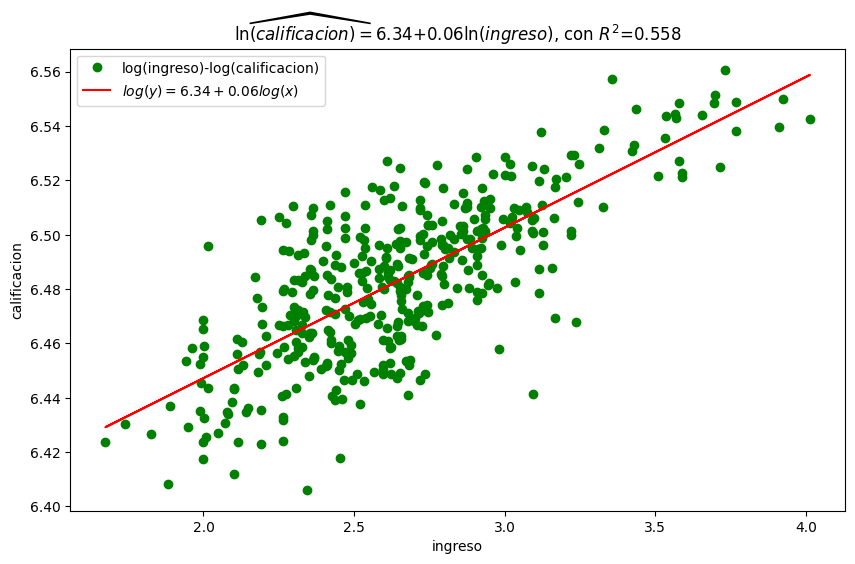

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

plt.plot(np.log(avginc),np.log(testscr),data=CA9899,color='g',marker='o',linestyle='',label='log(ingreso)-log(calificacion)')
plt.plot(np.log(avginc),reg_llog.fittedvalues,color='red',linestyle='-',label=f'$log(y)={llB0}+{llB1}log(x)$')
#
plt.ylabel ('calificacion')
plt.xlabel ('ingreso')
#   titulo
plt.title(r'$\widehat{\ln(calificacion)}=$'f'{llB0}+{llB1}' r'$\ln(ingreso)$, con $R^2$='f'{Rsqrt_llB}', size=12)

plt.legend()
plt.savefig('Lineal_IC3.jpg')
plt.show()

## **4.4 Curva de ajuste de la regresión log-log**

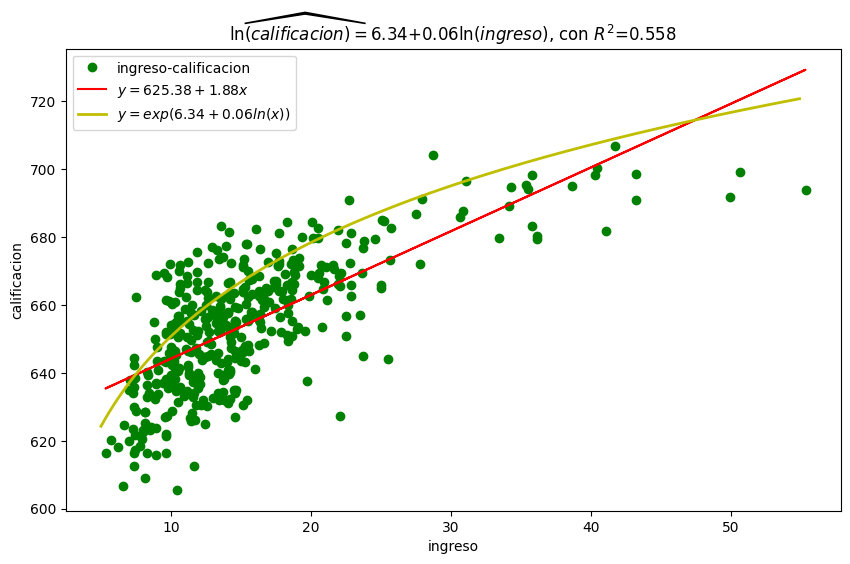

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

x=np.arange(5,55, 0.1)
ly=np.exp(llB0+llB1*np.log(x))

plt.plot('avginc','testscr',data=CA9899,color='g',marker='o',linestyle='',label='ingreso-calificacion')
plt.plot(CA9899['avginc'],reg_lineal.fittedvalues,color='red',linestyle='-',label=f'$y={B0}+{B1}x$')
plt.plot(x, ly, color='y',label=f'$y=exp({llB0}+{llB1}ln(x))$',linewidth=2)
#
plt.ylabel ('calificacion')
plt.xlabel ('ingreso')
#   titulo
plt.title(r'$\widehat{\ln(calificacion)}=$'f'{llB0}+{llB1}' r'$\ln(ingreso)$, con $R^2$='f'{Rsqrt_llB}', size=12)

plt.legend()
plt.savefig('Lineal_IC3.jpg')
plt.show()

# **Resultados de las cuatro regresiones**


Acontinuación se presenta el resultado de las cuatro regresiones, comenta cuál de estas eliges como el modelo que **mejor explica** los datos analizados y ¿qué puedes decir sobre la **mejor interpretación** de estos datos?.

In [ ]:
print(f'Tabla lin-lin: \n{Table01}\n')
print(f'R^2={round(reg_lineal.rsquared, 4)}\n')

print(f'Tabla lin-log: \n{Table02}\n')
print(f'R^2={round(reg_linlog.rsquared, 4)}\n')

print(f'Tabla log-lin: \n{Table03}\n')
print(f'R^2={round(reg_loglin.rsquared, 4)}\n')

print(f'Tabla log-log: \n{Table04}\n')
print(f'R^2={round(reg_llog.rsquared, 3)}\n')

Rsqrt_lB=reg_loglin.rsquared
Rsqrt_ll=reg_llog.rsquared


Tabla lin-lin: 
             beta   sigma     t-val  p-val
Intercept  625.38  1.5324  408.1060    0.0
avginc       1.88  0.0905   20.7565    0.0

R^2=0.5076

Tabla lin-log: 
                  beta   sigma     t-val  p-val
Intercept       557.83  4.2003  132.8062    0.0
np.log(avginc)   36.42  1.5710   23.1828    0.0

R^2=0.5625

Tabla log-lin: 
             beta   sigma      t-val  p-val
Intercept  6.4394  0.0024  2724.1613    0.0
avginc     0.0028  0.0001    20.3720    0.0

R^2=0.4982

Tabla log-log: 
                beta   sigma     t-val  p-val
Intercept       6.34  0.0065  981.9016    0.0
np.log(avginc)  0.06  0.0024   22.9617    0.0

R^2=0.558



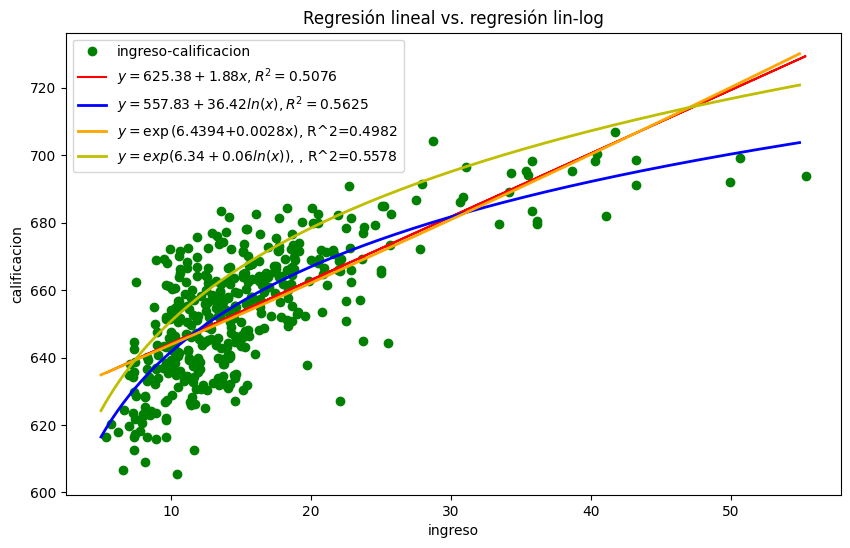

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))

x=np.arange(5,55, 0.1)

y=Bl0+Bl1*np.log(x)
ly=np.exp(lB0+lB1*x)
lly=np.exp(llB0+llB1*np.log(x))


plt.plot('avginc','testscr',data=CA9899,color='g',marker='o',linestyle='',label='ingreso-calificacion')
plt.plot(CA9899['avginc'],reg_lineal.fittedvalues,color='red',linestyle='-',label=f'$y={B0}+{B1}x, R^2={Rsqrt}$')
plt.plot(x, y, color='b',label=f'$y={Bl0}+{Bl1}ln(x), R^2={Rsqrt_Bl}$',linewidth=2)
plt.plot(x, ly, color='orange',label=r'$y=\exp$'f'({lB0}+{lB1}x), R^2={Rsqrt_lB:.4f}',linewidth=2)
plt.plot(x, lly, color='y',label=f'$y=exp({llB0}+{llB1}ln(x))$, , R^2={Rsqrt_ll:.4f}',linewidth=2)
#
plt.ylabel ('calificacion')
plt.xlabel ('ingreso')
#   titulo
plt.title('Regresión lineal vs. regresión lin-log', size=12)

plt.legend()
#plt.savefig('Lineal_IC3.jpg')
plt.show()